<!-- notebook-header -->
# Regressao: Modelos e Tecnicas

**Modulo:** 03 - Machine Learning  
**Tipo:** Aula com exercicios guiados e solucoes executaveis  
**Descricao:** Regressao linear, regularizacao, arvores, boosting, metricas e diagnostico de modelos.


# Regressao: Modelos e Tecnicas

### Tabela de Pre-requisitos

| Conceito | Notebook | Essencial |
|----------|----------|-----------|
| Regressao Linear | 1.4 | Sim |
| Normalizacao e Scaling | 2.2 | Sim |
| Validacao Cruzada | 0.8 | Importante |
| Classificacao | 3.1 | Recomendado |

### Mapa de Conceitos

```
REGRESSAO EM ML
    |
    +-- Modelos Lineares
    |     |-- Linear Regression (baseline)
    |     |-- Ridge (L2 regularizacao)
    |     |-- Lasso (L1, feature selection)
    |     |-- ElasticNet (L1 + L2)
    |
    +-- Modelos Nao-Lineares
    |     |-- Polynomial Regression
    |     |-- Random Forest Regressor
    |     |-- Gradient Boosting Regressor
    |     |-- SVR (Support Vector Regression)
    |
    +-- Avaliacao
          |-- R2, RMSE, MAE, MAPE
          |-- Learning Curves
          |-- Analise de Residuos
          |-- Pipeline completo
```

## Pre-requisitos e Fio Narrativo

**Pre-requisitos:** 1.4, 2.2
**Tempo estimado:** 10 horas

### Fio Narrativo

Em 3.1 voce aprendeu classificacao (prever categorias). Agora passa para regressao:
prever NUMEROS (preco de casa, temperatura, receita). Os conceitos sao os mesmos
(bias-variance, CV, tuning), mas as metricas e modelos mudam.
Voce vai desde regressao linear (baseline) ate Gradient Boosting (estado da arte para dados tabulares).

### Por que em ML?

Regressao eh tao fundamental quanto classificacao. Prever precos, demanda, consumo de energia,
risco financeiro -- sao todos problemas de regressao. Na industria, a maioria dos
modelos de forecasting e pricing sao regressoes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')

from itertools import product
from copy import deepcopy

# Datasets
from sklearn.datasets import (
    load_iris, load_breast_cancer, load_diabetes, load_digits,
    make_blobs, make_classification,
    make_regression, make_moons, make_circles,
)

# Pre-processing
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    LabelEncoder, OneHotEncoder, PolynomialFeatures,
)

# Model selection
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    GridSearchCV, RandomizedSearchCV, KFold, StratifiedKFold,
    learning_curve, validation_curve,
)

# Linear models
from sklearn.linear_model import (
    LogisticRegression, LinearRegression, Ridge, Lasso, ElasticNet,
)

# Trees and ensembles
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, GradientBoostingRegressor,
    BaggingClassifier, BaggingRegressor,
    AdaBoostClassifier, AdaBoostRegressor,
    VotingClassifier, StackingClassifier,
)

# Other classifiers
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture

# Dimensionality reduction
from sklearn.decomposition import PCA, KernelPCA, TruncatedSVD, NMF
from sklearn.manifold import TSNE, Isomap

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score,
    silhouette_score, calinski_harabasz_score, davies_bouldin_score,
)

# Pipeline
from sklearn.pipeline import Pipeline, make_pipeline

print('Setup OK - sklearn:', __import__('sklearn').__version__)

# === DATA SETUP (regressao) ===
from sklearn.metrics import mean_absolute_percentage_error
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target
feature_names = list(diabetes.feature_names)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)
_scaler = StandardScaler().fit(X_train)
X_train_scaled = _scaler.transform(X_train)
X_val_scaled = _scaler.transform(X_val)
X_test_scaled = _scaler.transform(X_test)


Setup OK - sklearn: 1.8.0


In [2]:
# Carregar dataset Diabetes (sklearn bundled, sem download)
housing = load_diabetes()
X = housing.data
y = housing.target
feature_names = list(housing.feature_names)

print(f'Amostras: {X.shape[0]}, Features: {X.shape[1]}')
print(f'Alvo (price): min={y.min():.2f}, max={y.max():.2f}, media={y.mean():.2f}')
print(f'Features: {feature_names}')

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f'\nTreino: {X_train.shape[0]}, Validacao: {X_val.shape[0]}, Teste: {X_test.shape[0]}')
print(f'Features normalizadas (media proxima de 0, std proximo de 1)')
print(f'X_train_scaled media: {X_train_scaled.mean(axis=0).mean():.4f}')
print(f'X_train_scaled std: {X_train_scaled.std(axis=0).mean():.4f}')

Amostras: 442, Features: 10
Alvo (price): min=25.00, max=346.00, media=152.13
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Treino: 282, Validacao: 71, Teste: 89
Features normalizadas (media proxima de 0, std proximo de 1)
X_train_scaled media: -0.0000
X_train_scaled std: 1.0000


## 1. Linear Regression Revisitada

### Analogia / Intuicao

Regressao linear eh como ajustar uma reta por uma nuvem de pontos:
encontrar os pesos que fazem a reta "passar o mais perto possivel" de todos os pontos.
O "mais perto possivel" eh definido pelo MSE (soma dos erros ao quadrado).

### Definicao Formal

Minimiza L = (1/n) * ||Xw - y||^2.
Solucao analitica: w = (X^T X)^-1 X^T y (normal equation).
Se X^T X eh singular (features correlacionadas), a inversa nao existe -> regularizacao.

### Por que em ML?

LR eh o baseline OBRIGATORIO de regressao. Se LR ja tem R2=0.90,
um modelo complexo precisa justificar sua complexidade adicional.
Alem disso, coeficientes de LR sao diretamente interpretaveis.

In [3]:
# Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

y_pred_train_lr = lr_model.predict(X_train_scaled)
y_pred_val_lr = lr_model.predict(X_val_scaled)
y_pred_test_lr = lr_model.predict(X_test_scaled)

print('=== LINEAR REGRESSION ===')
print(f'R2 Treino: {r2_score(y_train, y_pred_train_lr):.4f}')
print(f'R2 Validacao: {r2_score(y_val, y_pred_val_lr):.4f}')
print(f'R2 Teste: {r2_score(y_test, y_pred_test_lr):.4f}')
print(f'\nRMSE Teste: {np.sqrt(mean_squared_error(y_test, y_pred_test_lr)):.4f}')
print(f'MAE Teste: {mean_absolute_error(y_test, y_pred_test_lr):.4f}')
print(f'MAPE Teste: {mean_absolute_percentage_error(y_test, y_pred_test_lr):.4f}')

# Coeficientes
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coef': lr_model.coef_
}).sort_values('Coef', key=abs, ascending=False)

print('\nTop features por coeficiente absoluto:')
print(coef_df.to_string(index=False))

=== LINEAR REGRESSION ===
R2 Treino: 0.5306
R2 Validacao: 0.4701
R2 Teste: 0.4506

RMSE Teste: 53.9524
MAE Teste: 42.9076
MAPE Teste: 0.3683

Top features por coeficiente absoluto:
Feature       Coef
     s1 -44.199019
     s5  34.933089
    bmi  26.013394
     s2  22.969654
     bp  15.648868
     s4  13.897188
    sex -11.761602
     s3   7.806558
     s6   3.931046
    age   0.327810


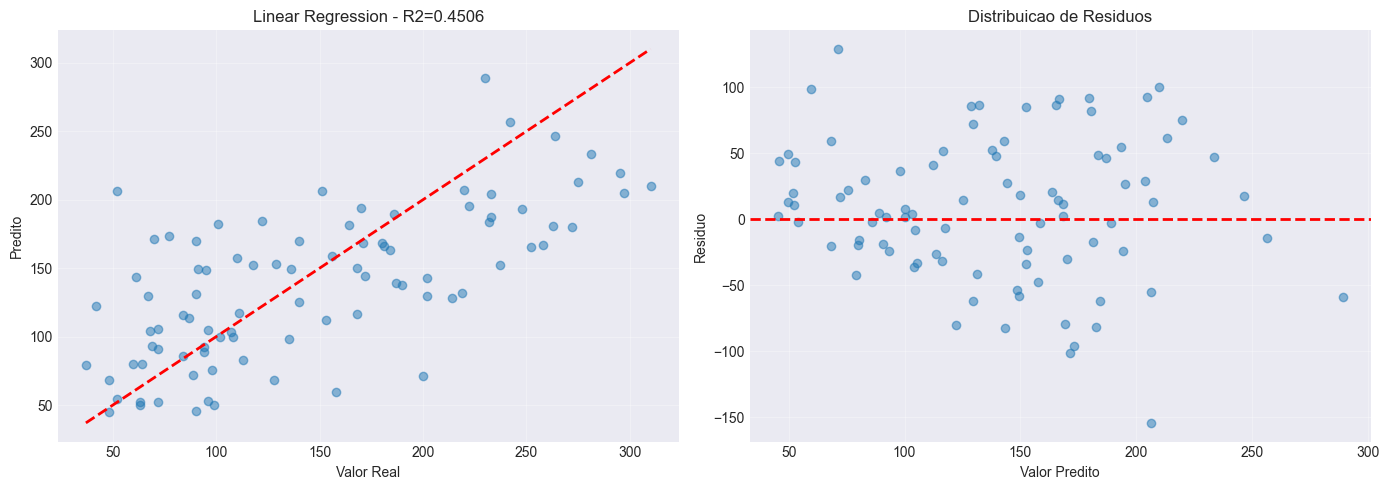

In [4]:
# Visualizar predicoes vs reais
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_test_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Valor Real')
plt.ylabel('Predito')
plt.title(f'Linear Regression - R2={r2_score(y_test, y_pred_test_lr):.4f}')
plt.grid(True, alpha=0.3)

# Residuos
residuals = y_test - y_pred_test_lr
plt.subplot(1, 2, 2)
plt.scatter(y_pred_test_lr, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Valor Predito')
plt.ylabel('Residuo')
plt.title('Distribuicao de Residuos')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**O que observar:**
- R2 mede proporcao da variancia explicada (1.0 = perfeito, 0 = media)
- No scatter real vs predito, pontos proximos da diagonal vermelha sao predicoes acuradas
- Residuos devem ser aleatorios (sem padrao) e centrados em zero
- Se residuos tem padrao (ex: aumentam com o valor predito), o modelo nao captura alguma relacao

**O que concluir:**
Linear Regression eh rapida e interpretavel, mas limitada a relacoes lineares.
Se R2 treino e teste sao similares e baixos, ha underfitting (modelo simples demais).
Se R2 treino >> R2 teste, ha overfitting. Ambos indicam que regularizacao ou modelos
nao-lineares podem ajudar.

### Conexao com outros notebooks

- Em 1.4 voce derivou a normal equation -- aqui a sklearn resolve numericamente
- Em 3.1 voce usou coeficientes de LR para interpretar features -- mesma logica aqui
- Em 2.2 (EDA) voce identificou relacoes que LR agora tenta modelar

## 2. Regularizacao: Ridge, Lasso, Elastic

Net

### Analogia / Intuicao

Sem regularizacao, o modelo pode dar pesos enormes para features ruidosas.
Ridge eh como colocar um "freio" que impede pesos de crescer demais (penaliza ||w||^2).
Lasso eh um "freio seletivo" que zera pesos de features irrelevantes (penaliza ||w||_1).
ElasticNet combina os dois.

### Definicao Formal

- **Ridge (L2):** L = MSE + alpha * sum(w_i^2) -- encolhe coeficientes uniformemente
- **Lasso (L1):** L = MSE + alpha * sum(|w_i|) -- pode zerar coeficientes (feature selection)
- **ElasticNet:** L = MSE + alpha * (r * ||w||_1 + (1-r) * ||w||^2) -- combina ambos

### Por que em ML?

Em datasets com muitas features correlacionadas, LR simples eh instavel
(coeficientes explodem). Regularizacao estabiliza e Lasso faz feature selection automatica.
Na industria, Ridge/Lasso sao os modelos lineares padrao -- quase ninguem usa LR pura.

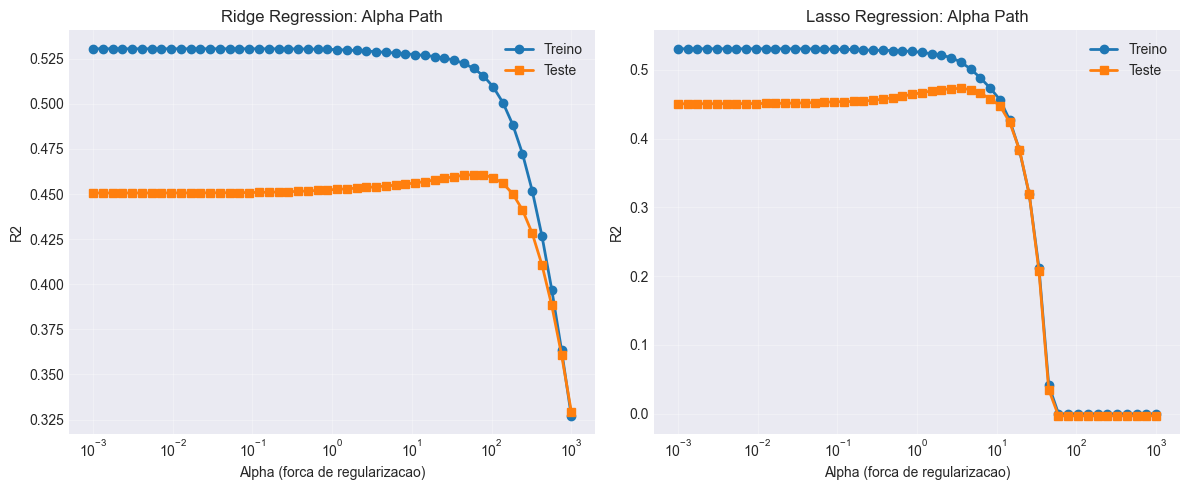

In [5]:
# Comparar diferentes alphas para Ridge
alphas = np.logspace(-3, 3, 50)
ridge_scores_train = []
ridge_scores_test = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train_scaled, y_train)
    ridge_scores_train.append(ridge.score(X_train_scaled, y_train))
    ridge_scores_test.append(ridge.score(X_test_scaled, y_test))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(alphas, ridge_scores_train, 'o-', label='Treino', linewidth=2)
plt.plot(alphas, ridge_scores_test, 's-', label='Teste', linewidth=2)
plt.xlabel('Alpha (forca de regularizacao)')
plt.ylabel('R2')
plt.xscale('log')
plt.title('Ridge Regression: Alpha Path')
plt.legend()
plt.grid(True, alpha=0.3)

# Lasso
lasso_scores_train = []
lasso_scores_test = []
lasso_coefs = []

for alpha in alphas:
    lasso = Lasso(alpha=alpha, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    lasso_scores_train.append(lasso.score(X_train_scaled, y_train))
    lasso_scores_test.append(lasso.score(X_test_scaled, y_test))
    lasso_coefs.append(lasso.coef_)

plt.subplot(1, 2, 2)
plt.plot(alphas, lasso_scores_train, 'o-', label='Treino', linewidth=2)
plt.plot(alphas, lasso_scores_test, 's-', label='Teste', linewidth=2)
plt.xlabel('Alpha (forca de regularizacao)')
plt.ylabel('R2')
plt.xscale('log')
plt.title('Lasso Regression: Alpha Path')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [6]:
# Feature Selection com Lasso
best_alpha_lasso = 0.001
lasso_best = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso_best.fit(X_train_scaled, y_train)

print('=== LASSO FEATURE SELECTION ===')
print(f'R2 Treino: {lasso_best.score(X_train_scaled, y_train):.4f}')
print(f'R2 Teste: {lasso_best.score(X_test_scaled, y_test):.4f}')
print(f'\nCoeficientes (features com peso > 0):')
for feat, coef in zip(feature_names, lasso_best.coef_):
    if coef != 0:
        print(f'  {feat}: {coef:.4f}')
print(f'Numero de features selecionadas: {np.sum(lasso_best.coef_ != 0)}/{len(feature_names)}')

=== LASSO FEATURE SELECTION ===
R2 Treino: 0.5306
R2 Teste: 0.4506

Coeficientes (features com peso > 0):
  age: 0.3286
  sex: -11.7599
  bmi: 26.0157
  bp: 15.6473
  s1: -44.0244
  s2: 22.8333
  s3: 7.7294
  s4: 13.8682
  s5: 34.8709
  s6: 3.9308
Numero de features selecionadas: 10/10


In [7]:
# ElasticNet (combinacao Ridge + Lasso)
elastic_net = ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
elastic_net.fit(X_train_scaled, y_train)

y_pred_elastic = elastic_net.predict(X_test_scaled)

print('\n=== ELASTICNET ===')
print(f'R2 Teste: {elastic_net.score(X_test_scaled, y_test):.4f}')
print(f'RMSE Teste: {np.sqrt(mean_squared_error(y_test, y_pred_elastic)):.4f}')


=== ELASTICNET ===
R2 Teste: 0.4529
RMSE Teste: 53.8372


**O que observar:**
- Alpha pequeno -> modelo proximo de LR pura (baixa regularizacao)
- Alpha grande -> coeficientes encolhidos a zero (alta regularizacao, underfitting)
- O "cotovelo" no grafico alpha vs R2 indica o alpha otimo
- Lasso zera features irrelevantes -- compare quais features sobrevivem

**O que concluir:**
Regularizacao eh quase sempre melhor que LR pura. Ridge funciona bem quando todas as
features sao relevantes. Lasso eh preferivel quando ha features irrelevantes (faz selecao
automatica). ElasticNet eh o compromisso quando voce nao tem certeza.

### Conexao com outros notebooks

- Em 1.4 voce viu normas L1 e L2 -- aqui elas sao usadas como penalidades
- Em 2.2 (EDA) voce identificou features correlacionadas -- Lasso resolve automaticamente
- Em 3.1 a regularizacao era via max_depth em arvores -- aqui eh via alpha

## 3. Polynomial Regression

### Analogia / Intuicao

Se os dados nao seguem uma reta, talvez sigam uma parabola (grau 2) ou curva (grau 3).
Polynomial Regression cria novas features (x^2, x*y, x^3...) e aplica LR nesse espaco expandido.
Problema: grau alto = muitas features = overfitting.

### Definicao Formal

Polynomial
Features(degree=d) transforma [x1, x2] em [x1, x2, x1^2, x1*x2, x2^2, ...].
Para d features e grau g: numero de features = C(d+g, g). Crece MUITO rapido.

### Por que em ML?

Polynomial Regression eh util quando relacoes nao-lineares sao simples (quadraticas, cubicas).
Para relacoes complexas, prefira Random Forest ou Gradient Boosting.
O principal valor pedagogico eh ilustrar o trade-off bias-variance visualmente.

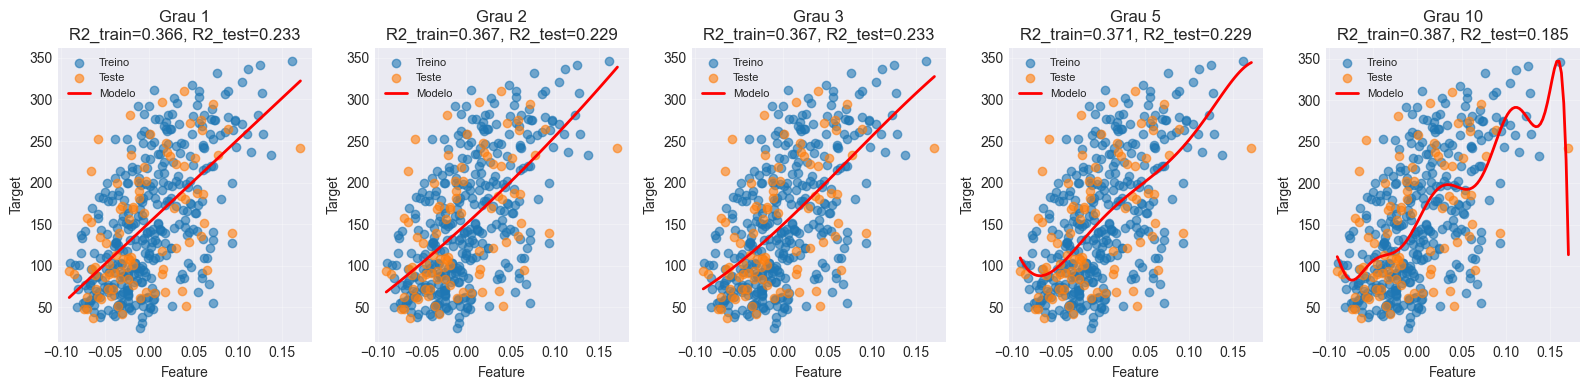

Observacao: Graus altos causam overfitting (R2 treino alto, teste baixo)


In [8]:
# Polynomial Regression com 1 feature (simplificado para visualizacao)
data_simple = load_diabetes()
X_simple = data_simple.data[:, [2]]  # Uma feature
y_simple = data_simple.target

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Graus de polinomio
degrees = [1, 2, 3, 5, 10]
fig, axes = plt.subplots(1, len(degrees), figsize=(16, 4))

for idx, degree in enumerate(degrees):
    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train_s)
    X_test_poly = poly.transform(X_test_s)
    
    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train_s)
    
    y_pred_train_p = poly_model.predict(X_train_poly)
    y_pred_test_p = poly_model.predict(X_test_poly)
    
    r2_train = r2_score(y_train_s, y_pred_train_p)
    r2_test = r2_score(y_test_s, y_pred_test_p)
    
    # Plotar
    axes[idx].scatter(X_train_s, y_train_s, alpha=0.6, label='Treino')
    axes[idx].scatter(X_test_s, y_test_s, alpha=0.6, label='Teste')
    
    X_range = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    y_range = poly_model.predict(X_range_poly)
    axes[idx].plot(X_range, y_range, 'r-', linewidth=2, label='Modelo')
    
    axes[idx].set_title(f'Grau {degree}\nR2_train={r2_train:.3f}, R2_test={r2_test:.3f}')
    axes[idx].set_ylabel('Target')
    axes[idx].set_xlabel('Feature')
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print('Observacao: Graus altos causam overfitting (R2 treino alto, teste baixo)')

**O que observar:**
- Grau 1 (linear): underfitting -- nao captura curvatura nos dados
- Grau 2-3: melhora progressiva -- captura relacoes nao-lineares simples
- Grau 5+: overfitting -- curva se ajusta ao ruido do treino mas generaliza mal
- R2 treino sempre sobe com grau maior; R2 teste sobe e depois DESCE

**O que concluir:**
Polynomial Regression demonstra bias-variance na pratica: grau baixo = alto bias,
grau alto = alta variance. O grau otimo balanceia os dois.
Na pratica, use Ridge com features polinomiais (regularizacao controla overfitting).

### Conexao com outros notebooks

- Bias-variance foi discutido teoricamente em 0.8 -- aqui voce VE visualmente
- Em 3.1 a mesma tensao aparecia com max_depth em arvores
- Em modulos futuros, redes neurais resolvem nao-linearidades sem features manuais

## 4. Ensemble Methods para Regressao

### Analogia / Intuicao

Assim como em classificacao (3.1), ensembles combinam muitos modelos fracos em um forte.
Random Forest media muitas arvores (reduz variance). Gradient Boosting treina arvores
sequencialmente, cada uma corrigindo os erros da anterior (reduz bias E variance).

### Definicao Formal

- **Random Forest Regressor:** media das predicoes de N arvores treinadas em bootstrap samples
- **Gradient Boosting:** treina arvores nos RESIDUOS das anteriores: f(x) = sum(h_i(x))
  onde cada h_i ajusta os residuos de sum(h_1..h_{i-1})

### Por que em ML?

Gradient Boosting (XGBoost, LightGBM) eh o modelo mais usado em competicoes de ML
para dados tabulares. Random Forest eh o melhor "default" (funciona bem sem tuning).
Juntos, dominam a industria de ML para dados estruturados.

In [9]:
# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_scaled, y_train)

y_pred_rf_reg = rf_reg.predict(X_test_scaled)

print('=== RANDOM FOREST REGRESSOR ===')
print(f'R2 Treino: {rf_reg.score(X_train_scaled, y_train):.4f}')
print(f'R2 Teste: {rf_reg.score(X_test_scaled, y_test):.4f}')
print(f'RMSE Teste: {np.sqrt(mean_squared_error(y_test, y_pred_rf_reg)):.4f}')
print(f'MAE Teste: {mean_absolute_error(y_test, y_pred_rf_reg):.4f}')

=== RANDOM FOREST REGRESSOR ===
R2 Treino: 0.9198
R2 Teste: 0.4323
RMSE Teste: 54.8438
MAE Teste: 44.3866


In [10]:
# Gradient Boosting Regressor
gb_reg = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_reg.fit(X_train_scaled, y_train)

y_pred_gb_reg = gb_reg.predict(X_test_scaled)

print('\n=== GRADIENT BOOSTING REGRESSOR ===')
print(f'R2 Treino: {gb_reg.score(X_train_scaled, y_train):.4f}')
print(f'R2 Teste: {gb_reg.score(X_test_scaled, y_test):.4f}')
print(f'RMSE Teste: {np.sqrt(mean_squared_error(y_test, y_pred_gb_reg)):.4f}')
print(f'MAE Teste: {mean_absolute_error(y_test, y_pred_gb_reg):.4f}')


=== GRADIENT BOOSTING REGRESSOR ===
R2 Treino: 0.9931
R2 Teste: 0.3553
RMSE Teste: 58.4461
MAE Teste: 48.5695


**O que observar:**
- RF tem R2 treino MUITO alto (proximo de 1.0) -- normal para ensembles de arvores
- O gap treino-teste de RF indica algum overfitting (controlado por max_depth)
- Gradient Boosting tende a ter gap menor que RF (regularizacao via learning_rate)
- RMSE e MAE podem contar historias diferentes: MAE eh robusto a outliers, RMSE penaliza mais

**O que concluir:**
Ensembles superam modelos lineares em quase todos os datasets tabulares.
Gradient Boosting eh especialmente poderoso mas requer tuning cuidadoso (learning_rate,
n_estimators, max_depth). Random Forest eh mais robusto a hiperparametros ruins.

### Conexao com outros notebooks

- Em 3.1 voce usou RF e viu feature importances -- mesma logica para regressao
- Em 3.3 voce estudara arvores e ensembles em profundidade
- Gradient Boosting sera detalhado em 3.3 com XGBoost e LightGBM

## 5. SVR (Support Vector Regression)

### Analogia / Intuicao

SVM para classificacao encontra a "rua mais larga" entre classes. SVR encontra
um "tubo" (epsilon-tube) que contem o maximo de pontos possivel.
Pontos fora do tubo sao penalizados; pontos dentro sao ignorados.

### Definicao Formal

SVR minimiza ||w||^2 + C * sum(max(0, |y_i - f(x_i)| - epsilon)).
Epsilon define a largura do tubo (tolerancia a erros).
C controla o trade-off entre tubo suave e fidelidade aos dados.

### Por que em ML?

SVR com kernel RBF eh poderoso para datasets de tamanho medio (<50k amostras).
Para datasets grandes, eh lento (O(n^2) a O(n^3)).
Na industria, SVR perdeu espaco para Gradient Boosting em dados tabulares,
mas ainda eh usado em series temporais e dados de sensores.

In [11]:
# SVR com grid search de C e epsilon

svr_params = {'C': [0.1, 1, 10, 100], 'epsilon': [0.01, 0.1, 0.5, 1]}
svr_base = SVR(kernel='rbf', gamma='scale')
grid_svr = GridSearchCV(svr_base, svr_params, cv=5, scoring='r2', n_jobs=-1, verbose=0)
grid_svr.fit(X_train_scaled, y_train)

print('=== SVR (Support Vector Regression) ===')
print(f'Melhores parametros: {grid_svr.best_params_}')
best_svr = grid_svr.best_estimator_
y_pred_svr = best_svr.predict(X_test_scaled)

print(f'R2 Teste: {best_svr.score(X_test_scaled, y_test):.4f}')
print(f'RMSE Teste: {np.sqrt(mean_squared_error(y_test, y_pred_svr)):.4f}')
print(f'MAE Teste: {mean_absolute_error(y_test, y_pred_svr):.4f}')

=== SVR (Support Vector Regression) ===
Melhores parametros: {'C': 10, 'epsilon': 1}
R2 Teste: 0.4554
RMSE Teste: 53.7157
MAE Teste: 43.4416


**O que observar:**
- Grid Search encontra C e epsilon otimos -- ambos impactam muito a performance
- SVR requer normalizacao obrigatoria (baseado em distancias)
- Tempo de treino eh significativamente maior que LR ou RF para datasets grandes

**O que concluir:**
SVR eh um modelo poderoso mas computacionalmente caro. Use quando o dataset eh
pequeno-medio e a performance importa mais que velocidade de treino.
Para datasets grandes, prefira Gradient Boosting.

### Conexao com outros notebooks

- Em 3.1 voce usou SVM para classificacao -- SVR eh a versao para regressao
- Em 3.4 voce aprofundara kernels e SVM
- A necessidade de normalizacao conecta com 2.2 (scaling)

## 6. Learning Curves e Bias-Variance

### Analogia / Intuicao

Learning curves mostram como o modelo melhora com mais dados de treino.
Se treino e validacao convergem em valor baixo: underfitting (modelo simples demais).
Se ficam separadas: overfitting (modelo complexo demais).

### Definicao Formal

Para cada tamanho de treino n: treinar modelo, avaliar em treino e validacao (CV).
Curva de treino: score(n, treino). Curva de validacao: score(n, val).
Gap = treino - validacao -> mede overfitting.

### Por que em ML?

Learning curves respondem: "preciso de mais dados?" Se a curva de validacao
ainda esta subindo, mais dados ajudam. Se ja estabilizou, mais dados nao ajudam
-- voce precisa de um modelo melhor ou features melhores.

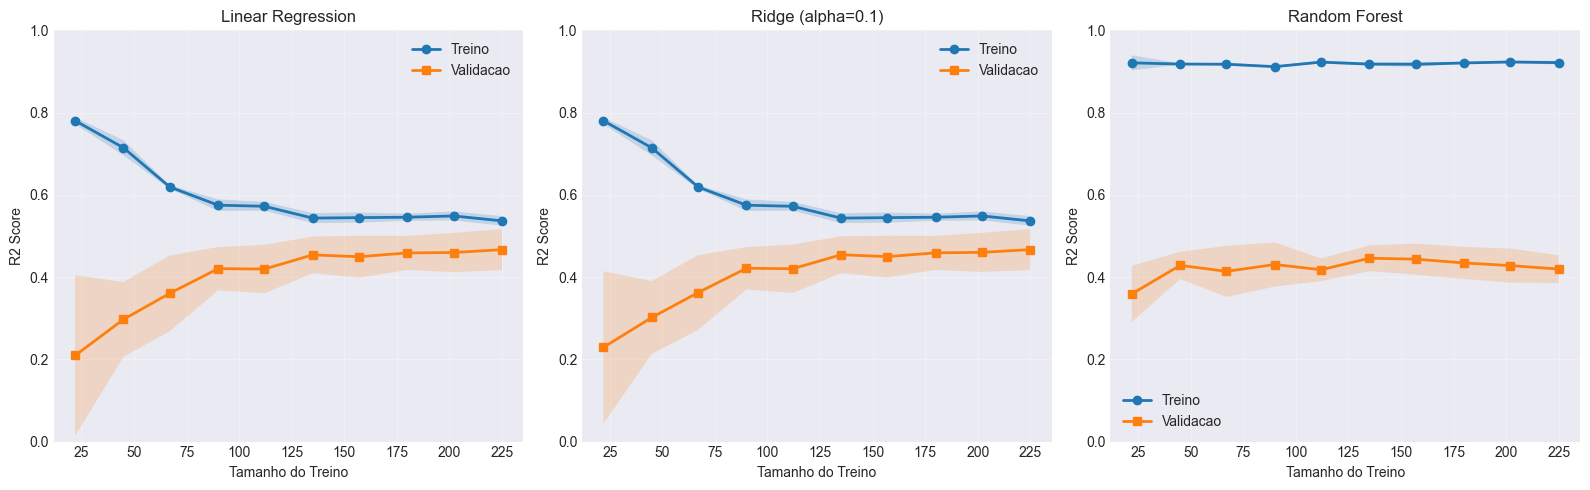

In [12]:
# Learning curves

train_sizes = np.linspace(0.1, 1.0, 10)
models_lc = {
    'Linear Regression': LinearRegression(),
    'Ridge (alpha=0.1)': Ridge(alpha=0.1),
    'Random Forest': RandomForestRegressor(max_depth=15, n_estimators=100, random_state=42, n_jobs=-1)
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, (name, model) in enumerate(models_lc.items()):
    train_sizes_abs, train_scores, val_scores = learning_curve(
        model, X_train_scaled, y_train, cv=5, train_sizes=train_sizes, 
        scoring='r2', n_jobs=-1
    )
    
    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)
    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)
    
    axes[idx].plot(train_sizes_abs, train_mean, 'o-', label='Treino', linewidth=2)
    axes[idx].fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.2)
    axes[idx].plot(train_sizes_abs, val_mean, 's-', label='Validacao', linewidth=2)
    axes[idx].fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.2)
    
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Tamanho do Treino')
    axes[idx].set_ylabel('R2 Score')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim([0, 1])

plt.tight_layout()
plt.show()

**O que observar:**
- LR: gap pequeno, scores baixos -> underfitting (bias alto)
- Ridge: similar a LR, margem levemente melhor com regularizacao
- RF: gap grande com poucos dados (overfitting), converge com mais dados
- Se validacao ainda sobe no fim do grafico, MAIS dados ajudam

**O que concluir:**
Learning curves sao a ferramenta diagnostica mais importante em ML.
Underfitting: use modelo mais complexo ou features melhores.
Overfitting: use regularizacao, mais dados, ou modelo mais simples.

### Conexao com outros notebooks

- Bias-variance tradeoff foi discutido em 0.8 -- aqui voce o VISUALIZA
- Em 3.1 os mesmos diagnosticos se aplicam a classificacao
- Em modulos futuros, learning curves guiam decisoes de coleta de dados

## 7. Metricas de Regressao

### Analogia / Intuicao

Em classificacao, acuracia pode ser enganosa. Em regressao, cada metrica
captura um aspecto diferente:
- RMSE eh como a nota de uma prova que penaliza muito erros grandes
- MAE eh como a nota que penaliza todos os erros igualmente
- R2 eh como a porcentagem de "explicacao" do modelo

### Definicao Formal

- **RMSE = sqrt(mean((y - y_pred)^2))** -- sensivel a outliers
- **MAE = mean(|y - y_pred|)** -- robusto a outliers
- **MAPE = mean(|y - y_pred| / y)** -- porcentagem (interpretavel)
- **R2 = 1 - SS_res / SS_tot** -- proporcao da variancia explicada

### Por que em ML?

A escolha da metrica define o que o modelo otimiza. RMSE penaliza erros grandes
(bom para previsao de risco). MAE eh mais robusto (bom para dados com outliers).
Na industria, a metrica eh definida pelo negocio, nao pelo data scientist.

=== RESUMO DE METRICAS ===
           Modelo       R2      RMSE       MAE     MAPE
Linear Regression 0.450589 53.952415 42.907592 0.368318
            Ridge 0.452932 53.837226 42.941381 0.367227
    Random Forest 0.432285 54.843798 44.386629 0.400415
Gradient Boosting 0.355257 58.446117 48.569492 0.438959
              SVR 0.455400 53.715650 43.441611 0.371970


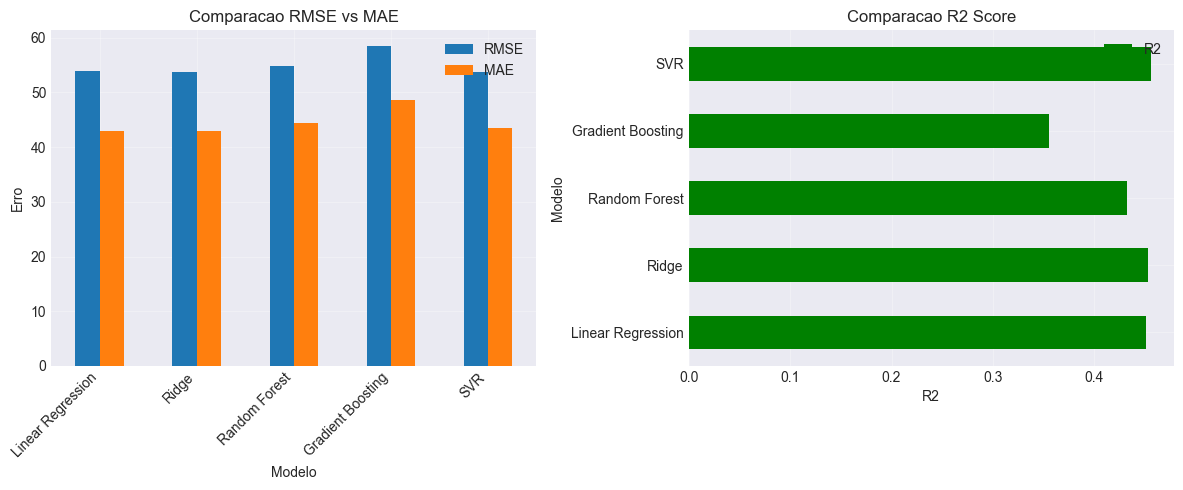

In [13]:
# Resumo de metricas para todos os modelos
models_summary = {
    'Linear Regression': y_pred_test_lr,
    'Ridge': elastic_net.predict(X_test_scaled),
    'Random Forest': y_pred_rf_reg,
    'Gradient Boosting': y_pred_gb_reg,
    'SVR': y_pred_svr
}

metrics_list = []
for model_name, y_pred in models_summary.items():
    metrics_list.append({
        'Modelo': model_name,
        'R2': r2_score(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'MAE': mean_absolute_error(y_test, y_pred),
        'MAPE': mean_absolute_percentage_error(y_test, y_pred)
    })

metrics_df = pd.DataFrame(metrics_list)
print('=== RESUMO DE METRICAS ===')
print(metrics_df.to_string(index=False))

# Visualizar RMSE e MAE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
metrics_df.set_index('Modelo')[['RMSE', 'MAE']].plot(kind='bar', ax=axes[0])
axes[0].set_ylabel('Erro')
axes[0].set_title('Comparacao RMSE vs MAE')
axes[0].legend()
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(True, alpha=0.3)

metrics_df.set_index('Modelo')[['R2']].plot(kind='barh', ax=axes[1], color='green')
axes[1].set_xlabel('R2')
axes[1].set_title('Comparacao R2 Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**O que observar:**
- Modelos podem ter rankings diferentes em RMSE vs MAE (se ha outliers)
- R2 negativo significa que o modelo eh PIOR que prever a media -- algo esta errado
- MAPE eh problematico quando y esta proximo de zero (divisao por zero)
- O melhor modelo depende da metrica: RF pode vencer em RMSE, LR em MAE

**O que concluir:**
Nunca confie em uma unica metrica. Compare RMSE, MAE e R2 juntos.
Se a diferenca entre RMSE e MAE eh grande, ha outliers nas predicoes.
O modelo ideal depende de qual tipo de erro o negocio tolera menos.

### Conexao com outros notebooks

- Em 3.1 voce usou metricas de classificacao (F1, AUC) -- aqui sao metricas de regressao
- Em 1.4 voce viu MSE como funcao de custo -- aqui RMSE eh sua raiz quadrada
- Em modulos futuros, a metrica do negocio guia a escolha final do modelo

## 8. Pipeline Completo

### Analogia / Intuicao

Pipeline eh como uma linha de montagem: normalizar -> transformar -> treinar -> prever.
Encapsular tudo em um objeto garante que transformacoes sao aplicadas consistentemente
em treino E teste, evitando data leakage.

### Por que em ML?

Sem Pipeline, eh facil esquecer de normalizar o test set, ou usar o scaler errado.
Pipeline do sklearn encapsula preprocessamento + modelo em um unico objeto
que pode ser serializado, versionado e deployado.

In [14]:
# Pipeline com preprocessamento + modelo
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', Ridge(alpha=0.1))
])

# Treinar com dados nao-normalizados (pipeline cuida disso)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    housing.data, housing.target, test_size=0.2, random_state=42
)

pipeline.fit(X_train_raw, y_train_raw)
y_pred_pipeline = pipeline.predict(X_test_raw)

print('=== PIPELINE (Ridge com Scaler) ===')
print(f'R2 Teste: {pipeline.score(X_test_raw, y_test_raw):.4f}')
print(f'RMSE Teste: {np.sqrt(mean_squared_error(y_test_raw, y_pred_pipeline)):.4f}')
print(f'\nPipeline steps: {[name for name, _ in pipeline.steps]}')

=== PIPELINE (Ridge com Scaler) ===
R2 Teste: 0.4528
RMSE Teste: 53.8429

Pipeline steps: ['scaler', 'regressor']


**O que observar:**
- O Pipeline aplica scaler.fit_transform no treino e scaler.transform no teste automaticamente
- Isso EVITA data leakage (o test set nao influencia o scaler)
- Pipeline pode ser salvo com joblib e usado diretamente em producao

**O que concluir:**
Sempre use Pipeline em projetos reais. Alem de prevenir data leakage,
torna o codigo mais limpo, testavel e deployavel.

### Conexao com outros notebooks

- Data leakage foi discutido em 2.2 (EDA) e 3.1 -- Pipeline previne automaticamente
- Em 2.4 voce viu pipelines de dados -- aqui eh o pipeline de MODELO
- Em modulos futuros, Pipeline sera a base de deployment

## 9. Exercicios Praticos

### Exercicio 1: Comparacao de Regularizacao

Compare Ridge, Lasso e ElasticNet com 15 valores de alpha.
Plote R2 vs alpha para os 3 metodos juntos no mesmo grafico.

In [ ]:
# TAREFA DO ALUNO: Exercicio 1 - Comparar regularizacoes
# Dica: usar np.logspace(-4, 2, 15) para alphas
# Para cada alpha, treinar Ridge, Lasso, ElasticNet
# Plotar R2 no test set vs alpha

alphas = None  # np.logspace(...)
ridge_r2 = None
lasso_r2 = None
elastic_r2 = None

print('Comparacao de regularizacoes:')

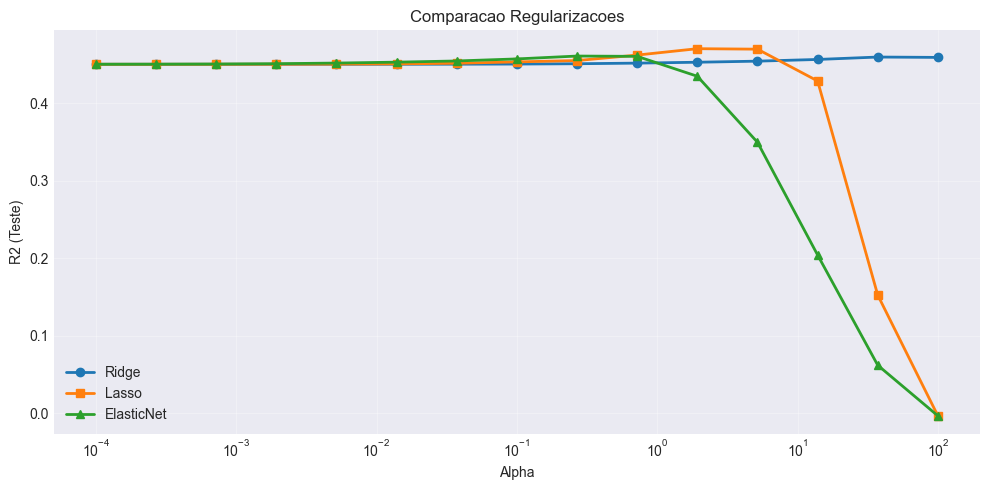

Melhor alpha Ridge: 37.2759 (R2=0.4599)


In [16]:
# SOLUCAO - Exercicio 1
import numpy as np
import matplotlib.pyplot as plt

alphas_custom = np.logspace(-4, 2, 15)
ridge_r2 = []
lasso_r2 = []
elastic_r2 = []

for alpha in alphas_custom:
    ridge_r2.append(Ridge(alpha=alpha).fit(X_train_scaled, y_train).score(X_test_scaled, y_test))
    lasso_r2.append(Lasso(alpha=alpha, max_iter=10000).fit(X_train_scaled, y_train).score(X_test_scaled, y_test))
    elastic_r2.append(ElasticNet(alpha=alpha, max_iter=10000).fit(X_train_scaled, y_train).score(X_test_scaled, y_test))

plt.figure(figsize=(10, 5))
plt.plot(alphas_custom, ridge_r2, 'o-', label='Ridge', linewidth=2)
plt.plot(alphas_custom, lasso_r2, 's-', label='Lasso', linewidth=2)
plt.plot(alphas_custom, elastic_r2, '^-', label='ElasticNet', linewidth=2)
plt.xlabel('Alpha')
plt.ylabel('R2 (Teste)')
plt.xscale('log')
plt.title('Comparacao Regularizacoes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_alpha_ridge = alphas_custom[np.argmax(ridge_r2)]
print(f'Melhor alpha Ridge: {best_alpha_ridge:.4f} (R2={max(ridge_r2):.4f})')

### Exercicio 2: Feature Engineering Polinomial

Crie features polinomiais de grau 2 para o dataset California Housing.
Compare Ridge com e sem features polinomiais.

In [ ]:
# TAREFA DO ALUNO: Exercicio 2 - Features polinomiais
# Dica: PolynomialFeatures(degree=2, include_bias=False)
# Treinar Ridge com X_train_scaled e X_train_poly
# Comparar R2

n_features_orig = None
n_features_poly = None
r2_sem = None
r2_com = None

print('Features polinomiais:')

In [18]:
# SOLUCAO - Exercicio 2

poly_feat = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly_feat.fit_transform(X_train_scaled)
X_test_poly = poly_feat.transform(X_test_scaled)

print(f'Features originais: {X_train_scaled.shape[1]}')
print(f'Features polinomiais (grau 2): {X_train_poly.shape[1]}')

r2_sem = Ridge(alpha=0.1).fit(X_train_scaled, y_train).score(X_test_scaled, y_test)
r2_com = Ridge(alpha=0.1).fit(X_train_poly, y_train).score(X_test_poly, y_test)

print(f'\nR2 sem polinomio: {r2_sem:.4f}')
print(f'R2 com polinomio: {r2_com:.4f}')
print(f'Melhoria: {(r2_com - r2_sem)*100:.2f} pontos percentuais')

Features originais: 10
Features polinomiais (grau 2): 65

R2 sem polinomio: 0.4509
R2 com polinomio: 0.3640
Melhoria: -8.68 pontos percentuais


### Exercicio 3: Analise de Residuos

Treine Gradient Boosting e analise os residuos:
histograma, Q-Q plot, e residuos vs predito.

In [ ]:
# TAREFA DO ALUNO: Exercicio 3 - Analise de residuos
# Dica: residuos = y_test - y_pred
# Plotar: scatter(y_pred, residuos), histograma, Q-Q plot

residuos = None
print('Analise de residuos:')

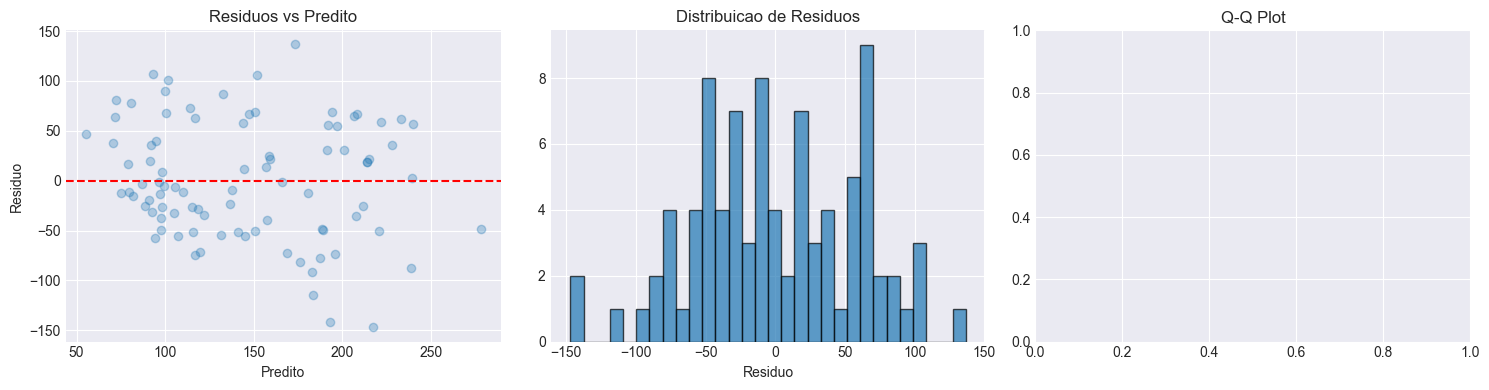

Teste de normalidade: p=0.466899
RMSE: 58.4461
Residuos normais: Sim


In [20]:
# SOLUCAO - Exercicio 3
import matplotlib.pyplot as plt
import numpy as np

gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_train_scaled, y_train)
y_pred_gb = gb.predict(X_test_scaled)
residuos = y_test - y_pred_gb

from scipy.stats import shapiro
_, p = shapiro(residuos)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(y_pred_gb, residuos, alpha=0.3)
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Residuo')
axes[0].set_title('Residuos vs Predito')

axes[1].hist(residuos, bins=30, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Residuo')
axes[1].set_title('Distribuicao de Residuos')

axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

print(f'Teste de normalidade: p={p:.6f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_gb)):.4f}')
print(f'Residuos normais: {"Sim" if p > 0.05 else "Nao"}')

### O que observar nos exercicios

- Regularizacao (Ex 1) mostra que alpha otimo varia entre Ridge, Lasso e ElasticNet
- Features polinomiais (Ex 2) podem melhorar performance mas aumentam risco de overfitting
- Residuos (Ex 3) revelam padroes que metricas agregadas escondem

**O que concluir:**
Os exercicios demonstram que regressao eficaz requer: regularizacao adequada,
features bem construidas, e diagnostico via residuos. Nenhum passo pode ser pulado.

### Por que em ML?

Na industria, analise de residuos eh OBRIGATORIA antes de deployar.
Residuos com padrao indicam que o modelo esta errado sistematicamente em certas faixas.

### Conexao com outros notebooks

- Regularizacao conecta com a teoria de bias-variance de 0.8
- Feature engineering polinomial estende o que voce fez em 2.2
- Analise de residuos sera usada em TAREFA DO ALUNOS os modulos futuros

### O que observar no panorama geral

- Modelos lineares (LR, Ridge, Lasso) sao rapidos e interpretaveis mas limitados
- Ensembles (RF, GB) dominam em performance mas sao "caixas pretas"
- A escolha entre interpretabilidade e performance eh o trade-off central de ML

**O que concluir:**
O workflow de regressao eh: baseline (LR) -> regularizacao (Ridge/Lasso) -> nao-linear (RF/GB)
-> diagnostico (residuos, learning curves) -> tuning (Grid Search). Este fluxo se aplica
a praticamente qualquer problema de regressao.

### Por que em ML?

Dominar este workflow eh suficiente para resolver 80% dos problemas de regressao da industria.
Os 20% restantes requerem deep learning ou modelos especializados.

### Conexao com outros notebooks

- Este notebook complementa 3.1 (classificacao) -- juntos cobrem ML supervisionado
- Em 3.3 voce aprofundara ensembles (XGBoost, LightGBM)
- No Modulo 4+, esses modelos serao usados em pipelines de producao

## 10. Erros Comuns e Armadilhas

### Erro 1: Nao normalizar para modelos baseados em distancia

SVR, Lasso e Ridge sao sensiveis a escala. Features com range [0, 1000] dominam
features com range [0, 1]. Solucao: StandardScaler ANTES do treino.

### Erro 2: Usar apenas R2 como metrica

R2=0.95 parece otimo, mas se RMSE eh enorme, as predicoes estao longe em valor absoluto.
Solucao: sempre reportar R2, RMSE e MAE juntos.

### Erro 3: Ignorar analise de residuos

Metricas agregadas escondem erros sistematicos. Residuos com padrao
(ex: subestima precos altos) indicam problema no modelo.
Solucao: plotar residuos vs predito e verificar se sao aleatorios.

### Erro 4: Polynomial features sem regularizacao

Grau 3 com 8 features = 120 features. Sem regularizacao, overfitting eh garantido.
Solucao: sempre usar Ridge ou Lasso com features polinomiais.

### Erro 5: Tunar hiperparametros no test set

Ajustar alpha, learning_rate etc olhando o test set causa overfitting sutil.
Solucao: usar GridSearchCV com CV interno; test set so no final.

### Erro 6: Comparar modelos com metricas diferentes

Dizer "RF eh melhor porque tem R2 maior" e "LR eh melhor porque tem MAE menor"
compara laranjas com bananas. Solucao: definir UMA metrica principal antes de comparar.

### Erro 7: Esquecer do Pipeline em producao

Treinar com StandardScaler mas esquecer de aplicar no test set em producao.
Resultado: predicoes erradas. Solucao: usar Pipeline do sklearn.

## 11. Resumo e Conexoes

### Hierarquia de Conceitos

```
REGRESSAO EM ML
|
+-- Modelos Lineares
|     |-- Linear Regression (baseline, interpretavel)
|     |-- Ridge (L2, estabiliza coeficientes)
|     |-- Lasso (L1, feature selection)
|     |-- ElasticNet (L1+L2, compromisso)
|
+-- Modelos Nao-Lineares
|     |-- Polynomial (features manuais, risco de overfit)
|     |-- Random Forest (ensemble, robusto, feature importance)
|     |-- Gradient Boosting (sequencial, estado da arte)
|     |-- SVR (kernel trick, datasets pequenos-medios)
|
+-- Avaliacao
|     |-- R2 (proporcao explicada)
|     |-- RMSE (penaliza erros grandes)
|     |-- MAE (robusto a outliers)
|     |-- Analise de residuos (diagnostico)
|     |-- Learning curves (bias-variance)
|
+-- Pipeline
      |-- Preprocessamento encapsulado
      |-- Previne data leakage
      |-- Facilita deployment
```

### Tabela de Conexoes

| Conceito | Onde apareceu antes | Onde sera usado |
|----------|-------------------|-----------------|
| Normal equation | 1.4 (Regressao) | Fundamenta LR |
| L1/L2 norms | 0.3 (Algebra Linear) | Ridge, Lasso |
| Bias-Variance | 0.8 (Validacao) | Learning curves |
| Feature scaling | 2.2 (EDA) | Pipeline |
| Cross-Validation | 3.1 (Classificacao) | Grid Search |
| Ensemble | 3.1 (RF classificacao) | 3.3 (profundidade) |

### Checklist de Competencias

- [ ] Sei treinar e avaliar LR, Ridge, Lasso, ElasticNet
- [ ] Entendo a diferenca entre R2, RMSE, MAE e MAPE
- [ ] Consigo criar e interpretar features polinomiais
- [ ] Sei treinar Random Forest e Gradient Boosting para regressao
- [ ] Consigo interpretar learning curves (bias vs variance)
- [ ] Sei analisar residuos para diagnostico do modelo
- [ ] Uso Pipeline para evitar data leakage

### Proximos Passos

1. **3.3 Arvores e Ensemble:** XGBoost, LightGBM, CatBoost em profundidade
2. **3.4 SVM e Kernels:** SVR avancado, kernels customizados
3. **3.5 Clustering:** Regressao nao-supervisionada (segmentacao)
4. **Modulo 4+:** Deploy de modelos de regressao em producao